In [231]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [232]:
df_credit = pd.read_csv('credit_record.csv')
df_application = pd.read_csv('application_record.csv')
df_merged = pd.merge(df_application, df_credit, on='ID', how='left')

In [233]:
print("Credit Record Data")
print("Shape:", df_credit.shape)
print("Columns:", df_credit.columns.tolist())
print("\nFirst 5 rows:")
print(df_credit.head())
print("\nData Info:")
print(df_credit.info())
print("\nSummary Statistics:")
print(df_credit.describe())

Credit Record Data
Shape: (1048575, 3)
Columns: ['ID', 'MONTHS_BALANCE', 'STATUS']

First 5 rows:
        ID  MONTHS_BALANCE STATUS
0  5001711               0      X
1  5001711              -1      0
2  5001711              -2      0
3  5001711              -3      0
4  5001712               0      C

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB
None

Summary Statistics:
                 ID  MONTHS_BALANCE
count  1.048575e+06    1.048575e+06
mean   5.068286e+06   -1.913700e+01
std    4.615058e+04    1.402350e+01
min    5.001711e+06   -6.000000e+01
25%    5.023644e+06   -2.900000e+01
50%    5.062104e+06   -1.700000e+01
75%    5.113856

In [234]:
# Missing values count
print("\nMissing Values in Credit Record:")
print(df_credit.isnull().sum())


Missing Values in Credit Record:
ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64


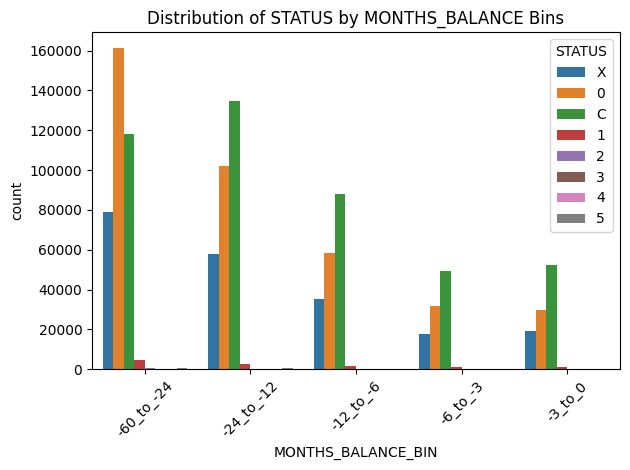

Correlation between MONTHS_BALANCE and STATUS_ORD: 0.17130661046029058


In [235]:
df_credit['MONTHS_BALANCE_BIN'] = pd.cut(
    df_credit['MONTHS_BALANCE'],
    bins=[-60, -24, -12, -6, -3, 0],  # Example bins
    labels=['-60_to_-24', '-24_to_-12', '-12_to_-6', '-6_to_-3', '-3_to_0']
)

# Step 2: Create a count plot of STATUS within these bins
sns.countplot(x='MONTHS_BALANCE_BIN', hue='STATUS', data=df_credit)
plt.title('Distribution of STATUS by MONTHS_BALANCE Bins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 3: (Optional) If you treat STATUS as ordinal, map it to numeric and compute correlation
status_mapping = {
    '0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, 'C': 6, 'X': -1
}
df_credit['STATUS_ORD'] = df_credit['STATUS'].map(status_mapping)

corr_value = df_credit[['MONTHS_BALANCE', 'STATUS_ORD']].corr().iloc[0,1]
print("Correlation between MONTHS_BALANCE and STATUS_ORD:", corr_value)

In [236]:
# EDA for application_record.csv
print("\n\nApplication Record Data")
print("Shape:", df_application.shape)
print("Columns:", df_application.columns.tolist())
print("\nFirst 5 rows:")
print(df_application.head())
print("\nData Info:")
print(df_application.info())
print("\nSummary Statistics:")
print(df_application.describe())

# Missing values count
print("\nMissing Values in Application Record:")
print(df_application.isnull().sum())



Application Record Data
Shape: (438557, 18)
Columns: ['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS']

First 5 rows:
        ID CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  CNT_CHILDREN  \
0  5008804           M            Y               Y             0   
1  5008805           M            Y               Y             0   
2  5008806           M            Y               Y             0   
3  5008808           F            N               Y             0   
4  5008809           F            N               Y             0   

   AMT_INCOME_TOTAL      NAME_INCOME_TYPE            NAME_EDUCATION_TYPE  \
0          427500.0               Working               Higher education   
1          427500.0               Working             

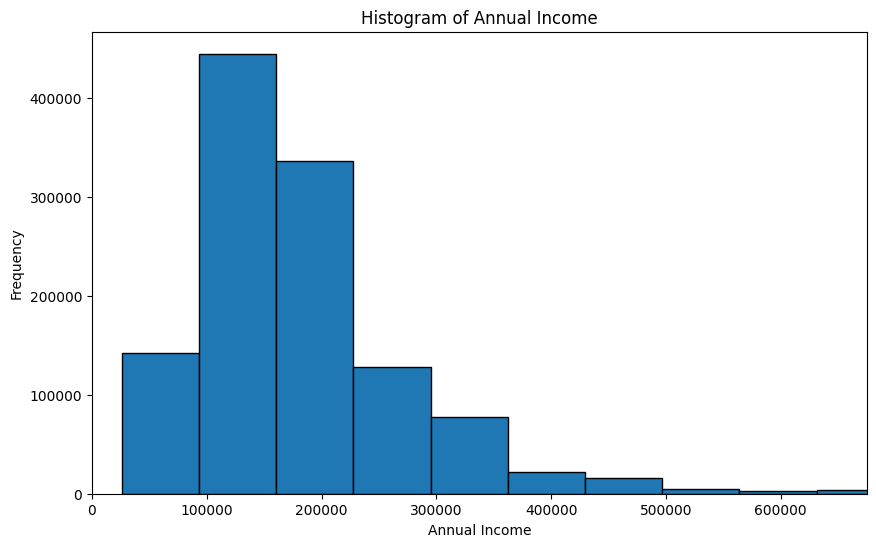

In [237]:
plt.figure(figsize=(10, 6))
plt.hist(df_merged['AMT_INCOME_TOTAL'].dropna(), bins=100, edgecolor='black')
plt.title('Histogram of Annual Income')
plt.xlabel('Annual Income')
plt.ylabel('Frequency')
plt.xlim(0, 675000)
plt.show()


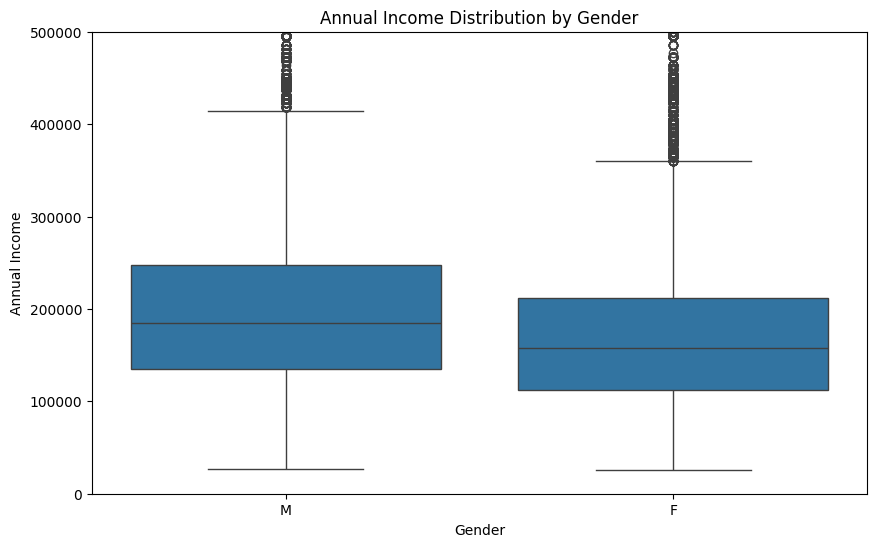

In [238]:
# ----------------------------
# Box Plot: Income Distribution by Gender
# ----------------------------
plt.figure(figsize=(10, 6))
sns.boxplot(x='CODE_GENDER', y='AMT_INCOME_TOTAL', data=df_application)
plt.title('Annual Income Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Annual Income')
plt.ylim(0, 500000)
plt.show()


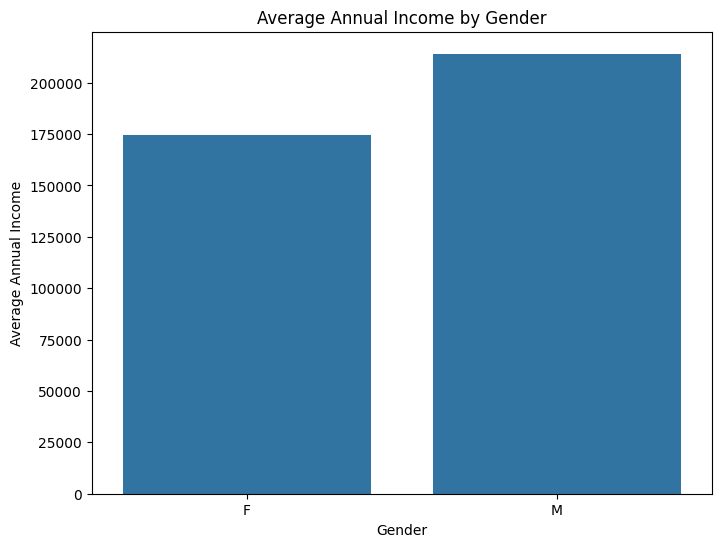

In [239]:
# ----------------------------
# Bar Plot: Average Income by Gender
# ----------------------------
# Calculate the average income for each gender
avg_income = df_application.groupby('CODE_GENDER')['AMT_INCOME_TOTAL'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(x='CODE_GENDER', y='AMT_INCOME_TOTAL', data=avg_income)
plt.title('Average Annual Income by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Annual Income')
plt.show()